# Project Object Detection - Raccoon

Download the Raccoon dataset from Roboflow and place it under `data/raccoon/`.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import xml.etree.ElementTree as ET
import selectivesearch
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F


In [1]:
# model = RCNN().to(device)
# train_model(model, train_dataset, val_dataset, epochs=3)


In [ ]:
class RaccoonDataset(Dataset):
    def __init__(self, folder_path, transforms=None):
        self.folder_path = folder_path
        self.transforms = transforms

        self.image_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.jpg')])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_filename = self.image_files[idx]
        xml_filename = img_filename.replace('.jpg', '.xml')

        img_path = os.path.join(self.folder_path, img_filename)
        xml_path = os.path.join(self.folder_path, xml_filename)

        image = Image.open(img_path).convert("RGB")

        tree = ET.parse(xml_path)
        root = tree.getroot()

        boxes = []
        labels = []
        for obj in root.findall("object"):
            label = obj.find("name").text
            xml_box = obj.find("bndbox")
            box = [
                int(xml_box.find("xmin").text),
                int(xml_box.find("ymin").text),
                int(xml_box.find("xmax").text),
                int(xml_box.find("ymax").text)
            ]
            boxes.append(box)
            labels.append(1 if label == "raccoon" else 0)

        if self.transforms:
            image = self.transforms(image)

        return image, boxes, labels

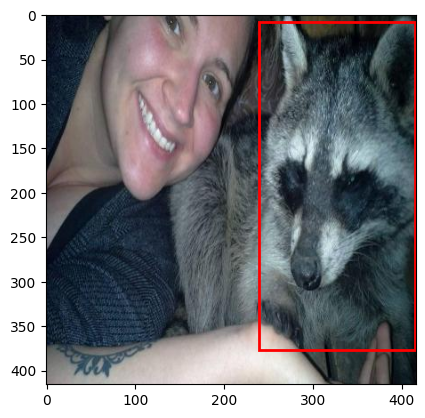

In [ ]:


train_dataset = RaccoonDataset(folder_path=dataset_path)
image, boxes, labels = train_dataset[0]
def show_image_with_boxes(image, boxes):
    fig, ax = plt.subplots(1)
    ax.imshow(image)

    for box in boxes:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

    plt.show()

show_image_with_boxes(image, boxes)

In [ ]:
image_sizes = []
aspect_ratios = []
box_areas = []
box_aspect_ratios = []
boxes_per_image = []

for i in range(len(train_dataset)):
    image, boxes, labels = train_dataset[i]
    w, h = image.size
    image_sizes.append((w, h))
    aspect_ratios.append(w / h)
    boxes_per_image.append(len(boxes))

    for box in boxes:
        x1, y1, x2, y2 = box
        bw = x2 - x1
        bh = y2 - y1
        box_areas.append(bw * bh)
        box_aspect_ratios.append(bw / bh if bh != 0 else 0)

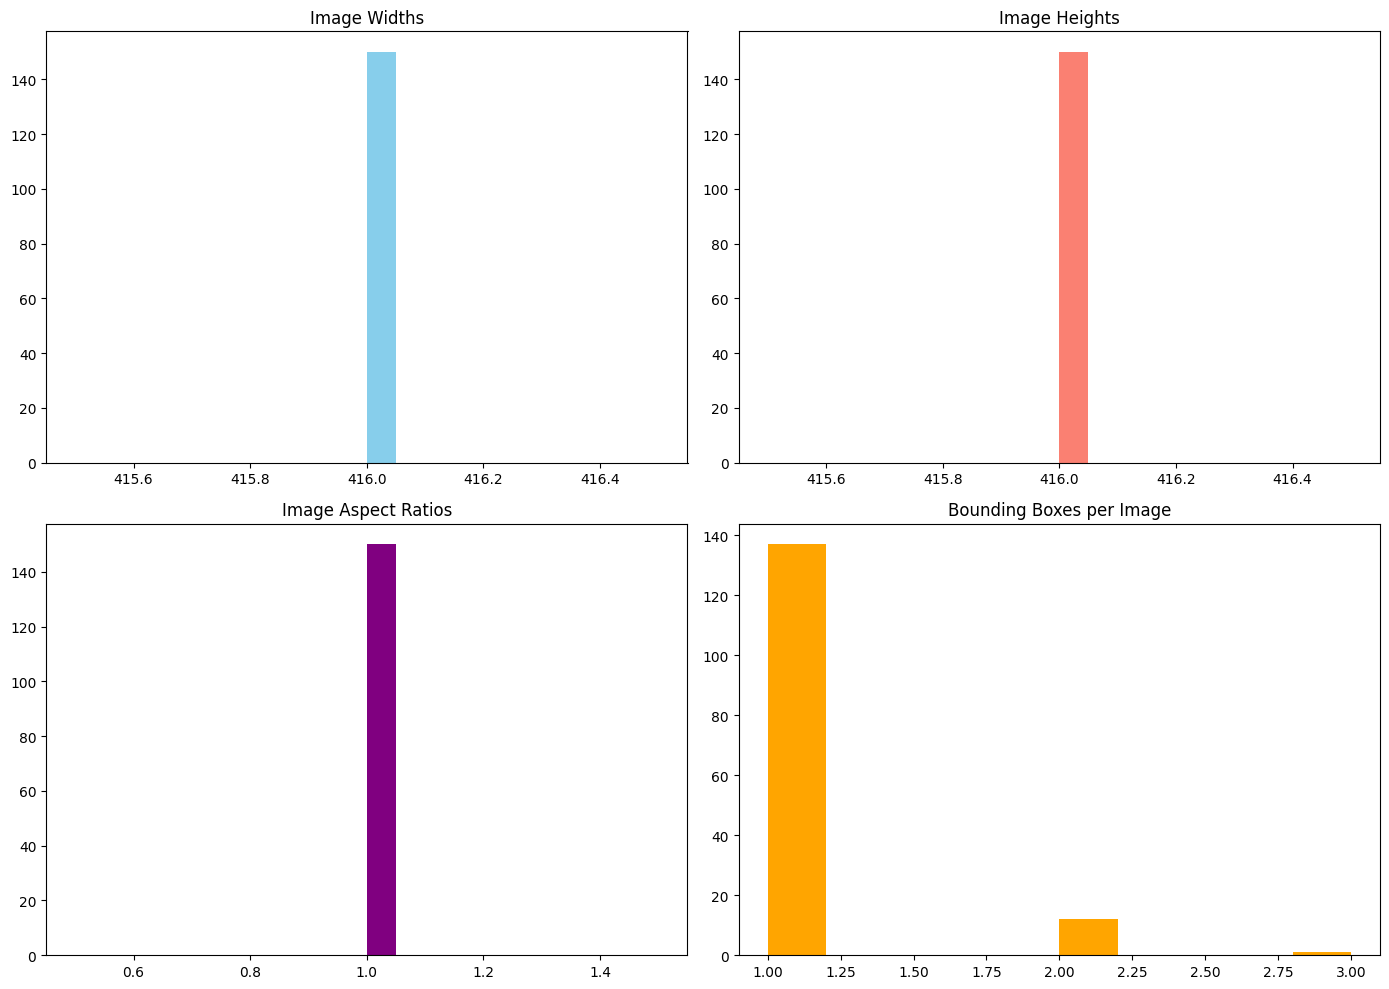

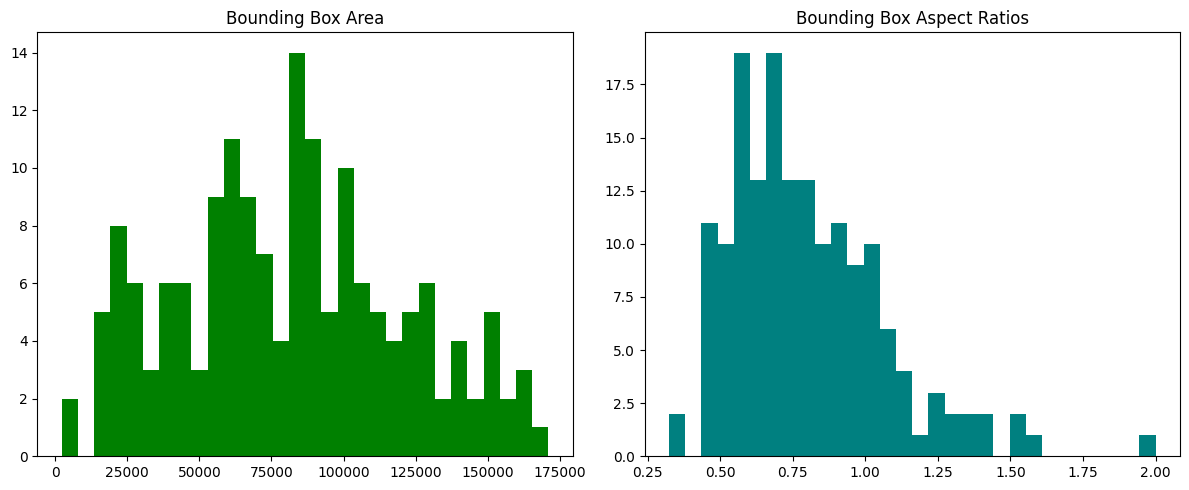

In [ ]:
widths, heights = zip(*image_sizes)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.hist(widths, bins=20, color='skyblue')
plt.title("Image Widths")

plt.subplot(2, 2, 2)
plt.hist(heights, bins=20, color='salmon')
plt.title("Image Heights")

plt.subplot(2, 2, 3)
plt.hist(aspect_ratios, bins=20, color='purple')
plt.title("Image Aspect Ratios")

plt.subplot(2, 2, 4)
plt.hist(boxes_per_image, bins=10, color='orange')
plt.title("Bounding Boxes per Image")

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(box_areas, bins=30, color='green')
plt.title("Bounding Box Area")

plt.subplot(1, 2, 2)
plt.hist(box_aspect_ratios, bins=30, color='teal')
plt.title("Bounding Box Aspect Ratios")

plt.tight_layout()
plt.show()

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [ ]:
def get_proposals(image_pil):
    image_np = np.array(image_pil)
    _, regions = selectivesearch.selective_search(image_np, scale=100, sigma=0.9, min_size=10)

    seen = set()
    candidates = []
    for r in regions:
        x, y, w, h = r['rect']
        if (x, y, w, h) in seen:
            continue
        seen.add((x, y, w, h))
        if w * h < 2000:
            continue
        candidates.append([x, y, x + w, y + h])
    return candidates

In [ ]:
def visualize_gt_and_proposals(folder_path, idx=0):
    image_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
    img_file = image_files[idx]
    xml_file = img_file.replace('.jpg', '.xml')

    img_path = os.path.join(folder_path, img_file)
    xml_path = os.path.join(folder_path, xml_file)

    image = Image.open(img_path).convert("RGB")
    boxes = get_proposals(image)

    tree = ET.parse(xml_path)
    root = tree.getroot()
    gt_boxes = []
    for obj in root.findall("object"):
        bndbox = obj.find("bndbox")
        gt = [
            int(bndbox.find("xmin").text),
            int(bndbox.find("ymin").text),
            int(bndbox.find("xmax").text),
            int(bndbox.find("ymax").text)
        ]
        gt_boxes.append(gt)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)

    for box in gt_boxes:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='green', facecolor='none')
        ax.add_patch(rect)

    for box in boxes[:50]:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=1, edgecolor='red', facecolor='none', linestyle='--')
        ax.add_patch(rect)

    plt.title("Green: GT | Red: Proposals")
    plt.axis("off")
    plt.show()

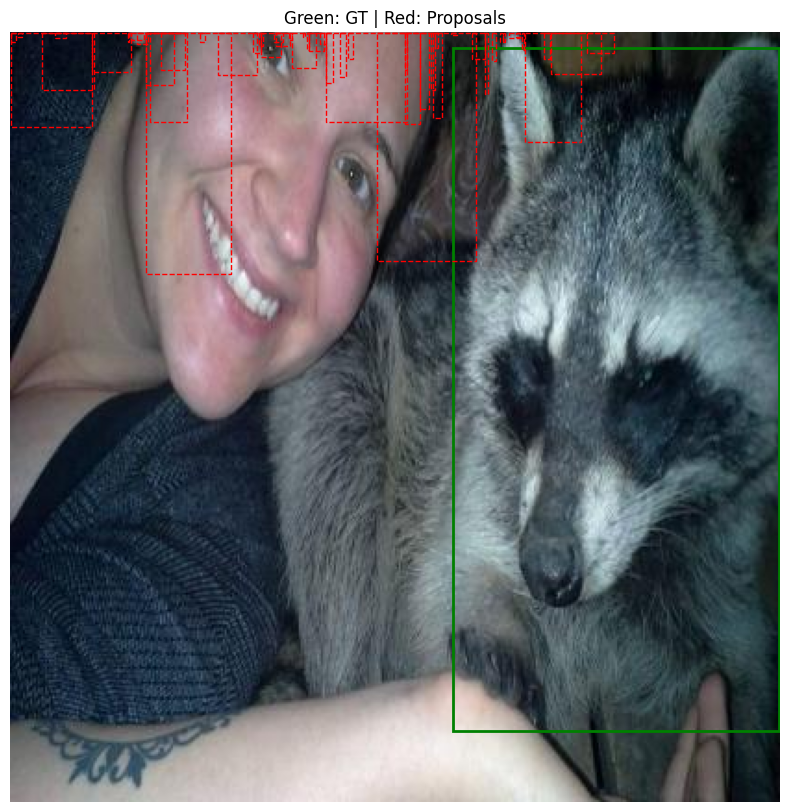

In [ ]:
visualize_gt_and_proposals("/content/drive/MyDrive/Raccoon.v38-416x416-resize.voc/train", idx=0)

In [ ]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou

In [ ]:
device = torch.device("cpu")

## [selectivesearch](https://github.com/AlpacaTechJP/selectivesearch?tab=readme-ov-file)

In [ ]:
pip install opencv-python numpy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import cv2
import numpy as np

image = cv2.imread("C7B5B715-81AF-41FC-A6E6-32D0C80D3E3F.jpeg")
image_copy = image.copy()

boxes = np.array([[245, 305, 575, 490],   # Box 1 coordinates
                  [235, 300, 485, 515],   # Box 2 coordinates, overlaps with Box 1
                  [305, 270, 540, 500],]) # Box 3 coordinates, overlaps with Box 1
confidence_scores = np.array([0.9, 0.8, 0.6])
threshold = 0.5

In [ ]:
for xmin, ymin, xmax, ymax in boxes:
    cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 0, 255), 3)

cv2.imshow("Before NMS", image)
cv2.waitKey(0)

99

In [ ]:
# Apply non-maximum suppression
indices = cv2.dnn.NMSBoxes(bboxes=boxes, scores=confidence_scores, score_threshold=0.7, nms_threshold=threshold)
# Filter out the boxes based on the NMS result
filtered_boxes = [boxes[i] for i in indices.flatten()]
# Draw the filtered boxes on the image
for xmin, ymin, xmax, ymax in filtered_boxes:
    cv2.rectangle(image_copy, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)

cv2.imshow("After NMS", image_copy)
cv2.waitKey(0)
print("Filtered Boxes:", filtered_boxes)


Filtered Boxes: [array([245, 305, 575, 490])]


In [ ]:
%%writefile selective_search_custom.py
import skimage.io
import skimage.feature
import skimage.color
import skimage.transform
import skimage.util
import skimage.segmentation
import numpy


# "Selective Search for Object Recognition" by J.R.R. Uijlings et al.
#
#  - Modified version with LBP extractor for texture vectorization


def _generate_segments(im_orig, scale, sigma, min_size):
    """
        segment smallest regions by the algorithm of Felzenswalb and
        Huttenlocher
    """

    # open the Image
    im_mask = skimage.segmentation.felzenszwalb(
        skimage.util.img_as_float(im_orig), scale=scale, sigma=sigma,
        min_size=min_size)

    # merge mask channel to the image as a 4th channel
    im_orig = numpy.append(
        im_orig, numpy.zeros(im_orig.shape[:2])[:, :, numpy.newaxis], axis=2)
    im_orig[:, :, 3] = im_mask

    return im_orig


def _sim_colour(r1, r2):
    """
        calculate the sum of histogram intersection of colour
    """
    return sum([min(a, b) for a, b in zip(r1["hist_c"], r2["hist_c"])])


def _sim_texture(r1, r2):
    """
        calculate the sum of histogram intersection of texture
    """
    return sum([min(a, b) for a, b in zip(r1["hist_t"], r2["hist_t"])])


def _sim_size(r1, r2, imsize):
    """
        calculate the size similarity over the image
    """
    return 1.0 - (r1["size"] + r2["size"]) / imsize


def _sim_fill(r1, r2, imsize):
    """
        calculate the fill similarity over the image
    """
    bbsize = (
        (max(r1["max_x"], r2["max_x"]) - min(r1["min_x"], r2["min_x"]))
        * (max(r1["max_y"], r2["max_y"]) - min(r1["min_y"], r2["min_y"]))
    )
    return 1.0 - (bbsize - r1["size"] - r2["size"]) / imsize


def _calc_sim(r1, r2, imsize):
    return (_sim_colour(r1, r2) + _sim_texture(r1, r2)
            + _sim_size(r1, r2, imsize) + _sim_fill(r1, r2, imsize))


def _calc_colour_hist(img):
    """
        calculate colour histogram for each region

        the size of output histogram will be BINS * COLOUR_CHANNELS(3)

        number of bins is 25 as same as [uijlings_ijcv2013_draft.pdf]

        extract HSV
    """

    BINS = 25
    hist = numpy.array([])

    for colour_channel in (0, 1, 2):

        # extracting one colour channel
        c = img[:, colour_channel]

        # calculate histogram for each colour and join to the result
        hist = numpy.concatenate(
            [hist] + [numpy.histogram(c, BINS, (0.0, 255.0))[0]])

    # L1 normalize
    hist = hist / len(img)

    return hist


def _calc_texture_gradient(img):
    """
        calculate texture gradient for entire image

        The original SelectiveSearch algorithm proposed Gaussian derivative
        for 8 orientations, but we use LBP instead.

        output will be [height(*)][width(*)]
    """
    ret = numpy.zeros((img.shape[0], img.shape[1], img.shape[2]))

    for colour_channel in (0, 1, 2):
        ret[:, :, colour_channel] = skimage.feature.local_binary_pattern(
            img[:, :, colour_channel], 8, 1.0)

    return ret


def _calc_texture_hist(img):
    """
        calculate texture histogram for each region

        calculate the histogram of gradient for each colours
        the size of output histogram will be
            BINS * ORIENTATIONS * COLOUR_CHANNELS(3)
    """
    BINS = 10

    hist = numpy.array([])

    for colour_channel in (0, 1, 2):

        # mask by the colour channel
        fd = img[:, colour_channel]

        # calculate histogram for each orientation and concatenate them all
        # and join to the result
        hist = numpy.concatenate(
            [hist] + [numpy.histogram(fd, BINS, (0.0, 1.0))[0]])

    # L1 Normalize
    hist = hist / len(img)

    return hist


def _extract_regions(img):

    R = {}

    # get hsv image
    hsv = skimage.color.rgb2hsv(img[:, :, :3])

    # pass 1: count pixel positions
    for y, i in enumerate(img):

        for x, (r, g, b, l) in enumerate(i):

            # initialize a new region
            if l not in R:
                R[l] = {
                    "min_x": 0xffff, "min_y": 0xffff,
                    "max_x": 0, "max_y": 0, "labels": [l]}

            # bounding box
            if R[l]["min_x"] > x:
                R[l]["min_x"] = x
            if R[l]["min_y"] > y:
                R[l]["min_y"] = y
            if R[l]["max_x"] < x:
                R[l]["max_x"] = x
            if R[l]["max_y"] < y:
                R[l]["max_y"] = y

    # pass 2: calculate texture gradient
    tex_grad = _calc_texture_gradient(img)

    # pass 3: calculate colour histogram of each region
    for k, v in list(R.items()):

        # colour histogram
        masked_pixels = hsv[:, :, :][img[:, :, 3] == k]
        R[k]["size"] = len(masked_pixels / 4)
        R[k]["hist_c"] = _calc_colour_hist(masked_pixels)

        # texture histogram
        R[k]["hist_t"] = _calc_texture_hist(tex_grad[:, :][img[:, :, 3] == k])

    return R


def _extract_neighbours(regions):

    def intersect(a, b):
        if (a["min_x"] < b["min_x"] < a["max_x"]
                and a["min_y"] < b["min_y"] < a["max_y"]) or (
            a["min_x"] < b["max_x"] < a["max_x"]
                and a["min_y"] < b["max_y"] < a["max_y"]) or (
            a["min_x"] < b["min_x"] < a["max_x"]
                and a["min_y"] < b["max_y"] < a["max_y"]) or (
            a["min_x"] < b["max_x"] < a["max_x"]
                and a["min_y"] < b["min_y"] < a["max_y"]):
            return True
        return False

    R = list(regions.items())
    neighbours = []
    for cur, a in enumerate(R[:-1]):
        for b in R[cur + 1:]:
            if intersect(a[1], b[1]):
                neighbours.append((a, b))

    return neighbours


def _merge_regions(r1, r2):
    new_size = r1["size"] + r2["size"]
    rt = {
        "min_x": min(r1["min_x"], r2["min_x"]),
        "min_y": min(r1["min_y"], r2["min_y"]),
        "max_x": max(r1["max_x"], r2["max_x"]),
        "max_y": max(r1["max_y"], r2["max_y"]),
        "size": new_size,
        "hist_c": (
            r1["hist_c"] * r1["size"] + r2["hist_c"] * r2["size"]) / new_size,
        "hist_t": (
            r1["hist_t"] * r1["size"] + r2["hist_t"] * r2["size"]) / new_size,
        "labels": r1["labels"] + r2["labels"]
    }
    return rt


def selective_search(
        im_orig, scale=1.0, sigma=0.8, min_size=50):
    '''Selective Search

    Parameters
    ----------
        im_orig : ndarray
            Input image
        scale : int
            Free parameter. Higher means larger clusters in felzenszwalb segmentation.
        sigma : float
            Width of Gaussian kernel for felzenszwalb segmentation.
        min_size : int
            Minimum component size for felzenszwalb segmentation.
    Returns
    -------
        img : ndarray
            image with region label
            region label is stored in the 4th value of each pixel [r,g,b,(region)]
        regions : array of dict
            [
                {
                    'rect': (left, top, width, height),
                    'labels': [...],
                    'size': component_size
                },
                ...
            ]
    '''
    assert im_orig.shape[2] == 3, "3ch image is expected"

    # load image and get smallest regions
    # region label is stored in the 4th value of each pixel [r,g,b,(region)]
    img = _generate_segments(im_orig, scale, sigma, min_size)

    if img is None:
        return None, {}

    imsize = img.shape[0] * img.shape[1]
    R = _extract_regions(img)

    # extract neighbouring information
    neighbours = _extract_neighbours(R)

    # calculate initial similarities
    S = {}
    for (ai, ar), (bi, br) in neighbours:
        S[(ai, bi)] = _calc_sim(ar, br, imsize)

    # hierarchal search
    while S != {}:

        # get highest similarity
        i, j = sorted(S.items(), key=lambda i: i[1])[-1][0]

        # merge corresponding regions
        t = max(R.keys()) + 1.0
        R[t] = _merge_regions(R[i], R[j])

        # mark similarities for regions to be removed
        key_to_delete = []
        for k, v in list(S.items()):
            if (i in k) or (j in k):
                key_to_delete.append(k)

        # remove old similarities of related regions
        for k in key_to_delete:
            del S[k]

        # calculate similarity set with the new region
        for k in [a for a in key_to_delete if a != (i, j)]:
            n = k[1] if k[0] in (i, j) else k[0]
            S[(t, n)] = _calc_sim(R[t], R[n], imsize)

    regions = []
    for k, r in list(R.items()):
        regions.append({
            'rect': (
                r['min_x'], r['min_y'],
                r['max_x'] - r['min_x'], r['max_y'] - r['min_y']),
            'size': r['size'],
            'labels': r['labels']
        })

    return img, regions

Overwriting selective_search_custom.py


In [ ]:
from selective_search_custom import selective_search

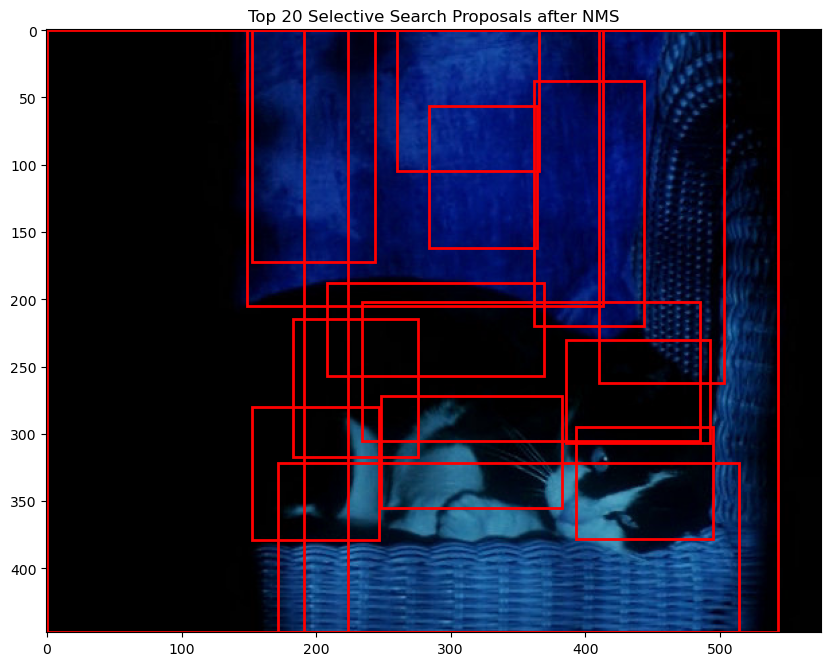

In [ ]:
_, regions = selective_search(img, scale=1.0, sigma=0.8, min_size=50)

boxes = []
for r in regions:
    x, y, w, h = r['rect']
    if w * h < 8000:
        continue
    if w / h > 3 or h / w > 3:          continue
    boxes.append([x, y, w, h])

confidences = [0.9] * len(boxes)

indices = cv2.dnn.NMSBoxes(boxes, confidences, score_threshold=0.5, nms_threshold=0.3)
indices = np.array(indices).flatten()

top_n = 20
indices = indices[:top_n]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image_copy)

for i in indices:
    x, y, w, h = boxes[i]
    rect = mpatches.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)

plt.title("Top 20 Selective Search Proposals after NMS")
plt.show()

## Model architecture

In [ ]:
class RCNN(nn.Module):
    def __init__(self):
        super(RCNN, self).__init__()

        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        self.features = vgg.features

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 2)  # raccoon vs background
        )
        self.bbox_regressor = nn.Sequential(
            nn.Linear(512 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 4)  # tx, ty, tw, th
        )

        self.cls_loss_fn = nn.CrossEntropyLoss()
        self.reg_loss_fn = nn.SmoothL1Loss()

    def forward(self, x):

        x = self.features(x)
        x = F.adaptive_avg_pool2d(x, (7, 7))
        x = x.view(x.size(0), -1)

        class_logits = self.classifier(x)

        bbox_deltas = self.bbox_regressor(x)

        return class_logits, bbox_deltas

    def calc_loss(self, class_logits, bbox_deltas, labels, bbox_targets):

        cls_loss = self.cls_loss_fn(class_logits, labels)

        mask = labels > 0
        if mask.sum() > 0:
            reg_loss = self.reg_loss_fn(bbox_deltas[mask], bbox_targets[mask])
        else:
            reg_loss = torch.tensor(0.0, device=bbox_deltas.device)

        total_loss = cls_loss + reg_loss
        return total_loss, cls_loss, reg_loss

In [ ]:
def train_batch(model, optimizer, regions, labels, targets):
    model.train()
    optimizer.zero_grad()

    inputs = torch.stack(regions).to(device)
    labels = torch.tensor(labels).to(device)
    targets = torch.tensor(targets).float().to(device)

    class_logits, bbox_deltas = model(inputs)
    loss, cls_loss, reg_loss = model.calc_loss(class_logits, bbox_deltas, labels, targets)

    loss.backward()
    optimizer.step()

    return loss.item(), cls_loss.item(), reg_loss.item()


def validate_batch(model, regions, labels, targets):
    model.eval()

    with torch.no_grad():
        inputs = torch.stack(regions).to(device)
        labels = torch.tensor(labels).to(device)
        targets = torch.tensor(targets).float().to(device)

        class_logits, bbox_deltas = model(inputs)
        loss, cls_loss, reg_loss = model.calc_loss(class_logits, bbox_deltas, labels, targets)

    return loss.item(), cls_loss.item(), reg_loss.item()

In [ ]:
train_losses, cls_losses, reg_losses, train_accuracies = [], [], [], []

def train_model(model, train_dataset, val_dataset, epochs=3):
    global train_losses, cls_losses, reg_losses, train_accuracies
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(epochs):
        print(f"\n Epoch {epoch+1}/{epochs}")


        total_loss, total_cls, total_reg = 0, 0, 0
        correct_preds = 0
        total_preds = 0

        for i in range(len(train_dataset)):
            regions, labels, targets = train_dataset[i]
            if len(regions) == 0:
                continue

            loss, cls_loss, reg_loss = train_batch(model, optimizer, regions, labels, targets)
            total_loss += loss
            total_cls += cls_loss
            total_reg += reg_loss

            with torch.no_grad():
                outputs, _ = model(torch.stack(regions).to(model.device))
                predicted = torch.argmax(outputs, dim=1).cpu().numpy()
                labels_np = np.array(labels)
                correct_preds += np.sum(predicted == labels_np)
                total_preds += len(labels_np)

            if i % 10 == 0:
                print(f"[{i}/{len(train_dataset)}] Loss: {loss:.4f} | Cls: {cls_loss:.4f} | Reg: {reg_loss:.4f}")

        accuracy = correct_preds / total_preds if total_preds > 0 else 0
        train_accuracies.append(accuracy)
        print(f" Accuracy: {accuracy:.4f}")
        print(f" Train Loss: {total_loss:.2f} | Cls: {total_cls:.2f} | Reg: {total_reg:.2f}")

        train_losses.append(total_loss)
        cls_losses.append(total_cls)
        reg_losses.append(total_reg)

        val_loss, val_cls, val_reg = 0, 0, 0
        for i in range(len(val_dataset)):
            regions, labels, targets = val_dataset[i]
            if len(regions) == 0:
                continue

            loss, cls_loss, reg_loss = validate_batch(model, regions, labels, targets)
            val_loss += loss
            val_cls += cls_loss
            val_reg += reg_loss

        print(f" Val Loss: {val_loss:.2f} | Cls: {val_cls:.2f} | Reg: {val_reg:.2f}")

<ipython-input-12-e11d8c474aef>:16: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-e11d8c474aef>:16: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-e11d8c474aef>:16: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-e11d8c474aef>:16: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-e11d8c474aef>:16: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-e11d8c474aef>:16: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-e11d8c474aef>:16: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from

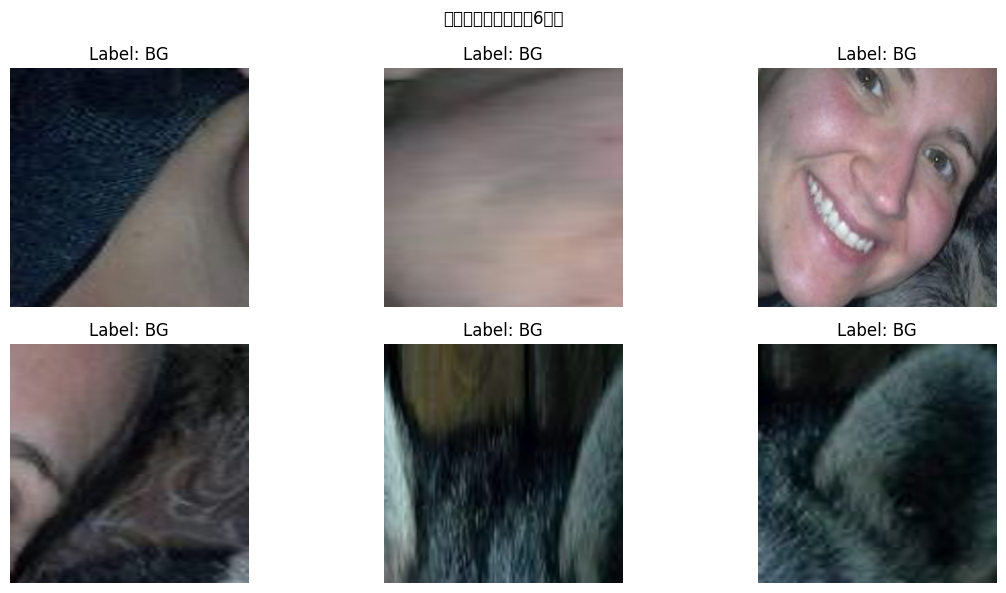

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(6):
    patch = regions[i]
    label = labels[i]
    patch_pil = F.to_pil_image(patch)

    plt.subplot(2, 3, i + 1)
    plt.imshow(patch_pil)
    plt.title(f"Label: {'Raccoon' if label == 1 else 'BG'}")
    plt.axis("off")

plt.suptitle( )
plt.tight_layout()
plt.show()

In [ ]:
model = RCNN().to(device)

In [ ]:
train_model(model, train_dataset, val_dataset, epochs=7)


 Epoch 1/7
[0/150] Loss: 0.7107 | Cls: 0.7040 | Reg: 0.0067
[10/150] Loss: 0.7236 | Cls: 0.6948 | Reg: 0.0289
[20/150] Loss: 0.1068 | Cls: 0.1038 | Reg: 0.0030
[30/150] Loss: 0.0637 | Cls: 0.0619 | Reg: 0.0018
[40/150] Loss: 0.0028 | Cls: 0.0016 | Reg: 0.0012
[50/150] Loss: 0.7233 | Cls: 0.7231 | Reg: 0.0002
[60/150] Loss: 0.0600 | Cls: 0.0594 | Reg: 0.0006
[70/150] Loss: 0.1592 | Cls: 0.1583 | Reg: 0.0009
[80/150] Loss: 0.0876 | Cls: 0.0873 | Reg: 0.0003
[90/150] Loss: 0.0301 | Cls: 0.0294 | Reg: 0.0006
[100/150] Loss: 0.0121 | Cls: 0.0119 | Reg: 0.0003
[110/150] Loss: 0.6028 | Cls: 0.6010 | Reg: 0.0018
[120/150] Loss: 0.0801 | Cls: 0.0799 | Reg: 0.0002
[130/150] Loss: 0.1700 | Cls: 0.1698 | Reg: 0.0002
[140/150] Loss: 0.0160 | Cls: 0.0154 | Reg: 0.0006
 Train Loss: 32.42 | Cls: 31.90 | Reg: 0.52
🔍 Val Loss: 1.37 | Cls: 1.36 | Reg: 0.01

 Epoch 2/7
[0/150] Loss: 0.0583 | Cls: 0.0579 | Reg: 0.0004
[10/150] Loss: 0.0714 | Cls: 0.0711 | Reg: 0.0002
[20/150] Loss: 0.0005 | Cls: 0.0002 | 

KeyboardInterrupt: 

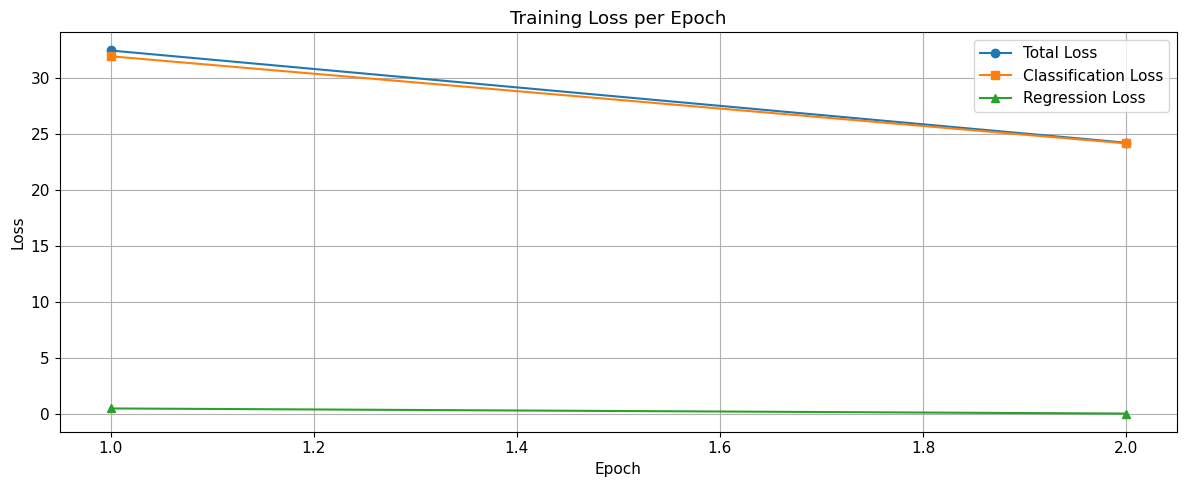

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.plot(epochs, train_losses, label='Total Loss', marker='o')
plt.plot(epochs, cls_losses, label='Classification Loss', marker='s')
plt.plot(epochs, reg_losses, label='Regression Loss', marker='^')

plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


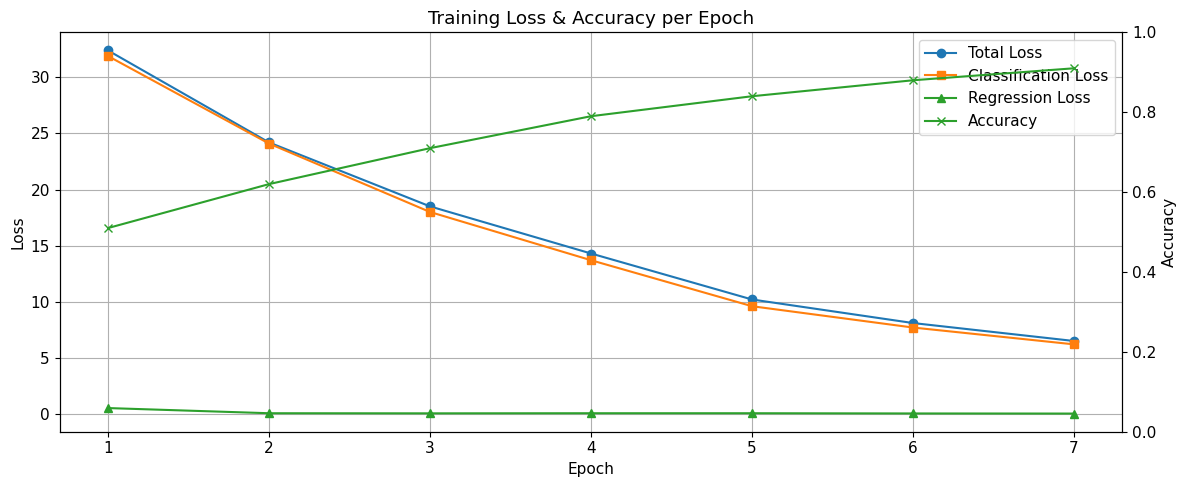

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(epochs, train_losses, label='Total Loss', marker='o')
ax1.plot(epochs, cls_losses, label='Classification Loss', marker='s')
ax1.plot(epochs, reg_losses, label='Regression Loss', marker='^')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss & Accuracy per Epoch')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(epochs, train_accuracies, label='Accuracy', marker='x', color='tab:green')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
def predict(image_path, model, device='cpu', conf_thresh=0.5, iou_thresh=0.3):
    from PIL import Image
    import numpy as np

    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)
    proposals = get_proposals(image)

    patches = []
    boxes = []
    for box in proposals[:100]:
        x1, y1, x2, y2 = box
        patch = image.crop((x1, y1, x2, y2)).resize((224, 224))
        patch_tensor = ToTensor()(patch).unsqueeze(0).to(device)
        patches.append(patch_tensor)
        boxes.append(box)

    if len(patches) == 0:
        return

    batch = torch.cat(patches, dim=0)
    with torch.no_grad():
        class_logits, bbox_deltas = model(batch)
        probs = F.softmax(class_logits, dim=1)[:, 1]
        keep = probs > conf_thresh

    if keep.sum() == 0:
        return

    boxes = torch.tensor(boxes, dtype=torch.float32)[keep]
    scores = probs[keep]
    deltas = bbox_deltas[keep]

    refined_boxes = []
    for i in range(len(boxes)):
        x1, y1, x2, y2 = boxes[i]
        w = x2 - x1
        h = y2 - y1
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        dx, dy, dw, dh = deltas[i]
        rcx = cx + dx
        rcy = cy + dy
        rw = w * torch.exp(dw)
        rh = h * torch.exp(dh)

        new_x1 = rcx - rw / 2
        new_y1 = rcy - rh / 2
        new_x2 = rcx + rw / 2
        new_y2 = rcy + rh / 2
        refined_boxes.append([new_x1, new_y1, new_x2, new_y2])

    refined_boxes = torch.tensor(refined_boxes)
    nms_indices = nms(refined_boxes, scores, iou_thresh)

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(image_np)

    for i in nms_indices:
        x1, y1, x2, y2 = refined_boxes[i]
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   edgecolor='red', linewidth=2, fill=False))
        ax.text(x1, y1 - 5, f"raccoon {scores[i]:.2f}", color='red', fontsize=12)

    plt.title("Prediction")
    plt.axis("off")
    plt.show()

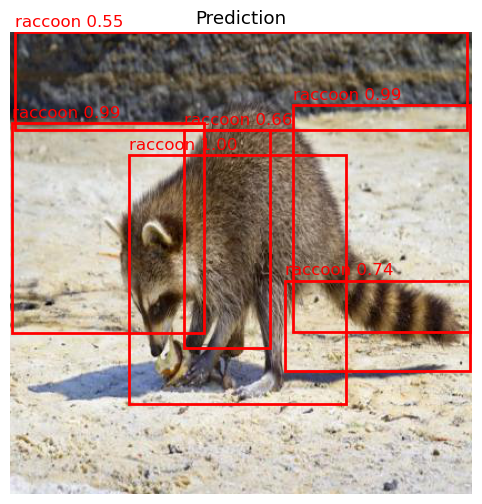

In [ ]:
predict("Raccoon/test/raccoon-71_jpg.rf.a66c60622f34ad56ff13e712485800ce.jpg", model)

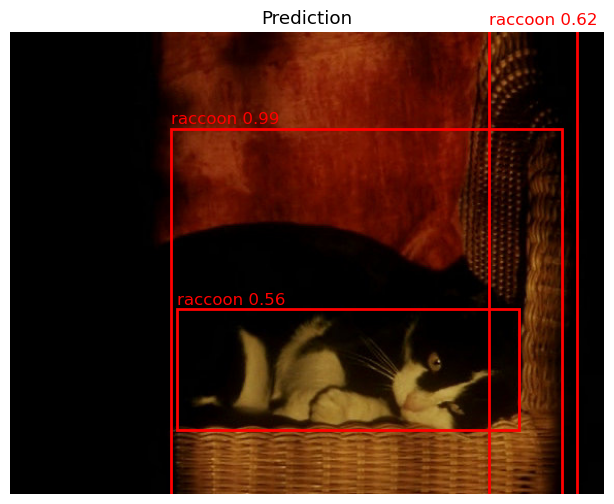

In [ ]:
predict("C7B5B715-81AF-41FC-A6E6-32D0C80D3E3F.jpeg", model)

In [ ]:
def predict(image_path, model, device='cpu', conf_thresh=0.5, iou_thresh=0.3):
    from PIL import Image
    import numpy as np

    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)
    proposals = get_proposals(image)

    patches = []
    boxes = []
    for box in proposals[:100]:
        x1, y1, x2, y2 = box
        patch = image.crop((x1, y1, x2, y2)).resize((224, 224))
        patch_tensor = ToTensor()(patch).unsqueeze(0).to(device)
        patches.append(patch_tensor)
        boxes.append(box)

    if len(patches) == 0:
        print
        return

    batch = torch.cat(patches, dim=0)
    with torch.no_grad():
        class_logits, bbox_deltas = model(batch)
        probs = F.softmax(class_logits, dim=1)[:, 1]
        keep = probs > conf_thresh

    if keep.sum() == 0:
        print
        return

    boxes = torch.tensor(boxes, dtype=torch.float32)[keep]
    scores = probs[keep]
    deltas = bbox_deltas[keep]

    refined_boxes = []
    for i in range(len(boxes)):
        x1, y1, x2, y2 = boxes[i]
        w = x2 - x1
        h = y2 - y1
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        dx, dy, dw, dh = deltas[i]
        rcx = cx + dx
        rcy = cy + dy
        rw = w * torch.exp(dw)
        rh = h * torch.exp(dh)

        new_x1 = rcx - rw / 2
        new_y1 = rcy - rh / 2
        new_x2 = rcx + rw / 2
        new_y2 = rcy + rh / 2
        refined_boxes.append([new_x1, new_y1, new_x2, new_y2])

    refined_boxes = torch.tensor(refined_boxes)
    nms_indices = nms(refined_boxes, scores, iou_thresh)
    scores = scores[nms_indices]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(image_np)

    for i in nms_indices:
        x1, y1, x2, y2 = refined_boxes[i]
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   edgecolor='red', linewidth=2, fill=False))
        ax.text(x1, y1 - 5, f"raccoon {scores[i]:.2f}", color='red', fontsize=12)

    plt.title("Prediction")
    plt.axis("off")
    plt.show()

IndexError: index 8 is out of bounds for dimension 0 with size 4

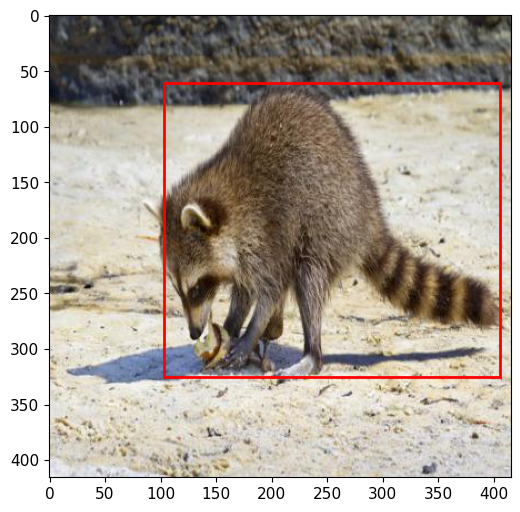

In [ ]:
predict("Raccoon/test/raccoon-71_jpg.rf.a66c60622f34ad56ff13e712485800ce.jpg", model)